# Paso 1. Acceda los datos y prepáralos para el análisis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
visits = pd.read_csv("/datasets/visits_log_us.csv")

In [3]:
visits.head(10)

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


In [4]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [5]:
visits.describe()

,Source Id,Uid
count,359400.000000,3.594000e+05
mean,3.750515,9.202557e+18
std,1.917116,5.298433e+18
min,1.000000,1.186350e+13
25%,3.000000,4.613407e+18
50%,4.000000,9.227413e+18
75%,5.000000,1.372824e+19
max,10.000000,1.844668e+19


In [6]:
visits.duplicated().sum()

0

In [7]:
visits.isna().sum()

Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

In [8]:
visits["Device"] = visits["Device"].astype("category")

In [9]:
visits["Start Ts"] = visits["Start Ts"].astype("datetime64[ns]")

In [10]:
visits["End Ts"] = visits["End Ts"].astype("datetime64[ns]")

In [11]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


In [12]:
orders = pd.read_csv("/datasets/orders_log_us.csv")

In [13]:
orders.head(10)

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [15]:
orders.describe()

,Revenue,Uid
count,50415.000000,5.041500e+04
mean,4.999647,9.098161e+18
std,21.818359,5.285742e+18
min,0.000000,3.135781e+14
25%,1.220000,4.533567e+18
50%,2.500000,9.102274e+18
75%,4.890000,1.368290e+19
max,2633.280000,1.844617e+19


In [16]:
orders.duplicated().sum()

0

In [17]:
orders.isna().sum()

Buy Ts     0
Revenue    0
Uid        0
dtype: int64

In [18]:
orders["Buy Ts"] = orders["Buy Ts"].astype("datetime64[ns]")

In [19]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [20]:
costs = pd.read_csv("/datasets/costs_us.csv")

In [21]:
costs.head(10)

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


In [22]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [23]:
costs.describe()

,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [24]:
costs.duplicated().sum()

0

In [25]:
costs.isna().sum()

source_id    0
dt           0
costs        0
dtype: int64

In [26]:
costs["dt"] = costs["dt"].astype("datetime64[ns]")

In [27]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


# Paso 2. Haz informes y calcula métricas

In [28]:
#VISITAS
#¿Cuántas personas lo usan cada día, semana y mes?

In [29]:
visits["month"] = visits["Start Ts"].dt.month

visits["week"] = visits["Start Ts"].dt.week

visits["date"] = visits["Start Ts"].dt.date

visits["date"] = visits["date"].astype("datetime64[ns]") 

In [30]:
visits

,Device,End Ts,Source Id,Start Ts,Uid,month,week,date
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,12,51,2017-12-20
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2,8,2018-02-19
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,7,26,2017-07-01
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,12,52,2017-12-27
...,...,...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,7,30,2017-07-29
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,1,4,2018-01-25
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,3,9,2018-03-03
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,11,44,2017-11-02


In [31]:
users_per_month = visits.groupby("month").agg({"Uid": "nunique"})

users_per_week = visits.groupby("week").agg({"Uid": "nunique"})

users_per_day = visits.groupby("date").agg({"Uid": "nunique"})

In [32]:
print("Visitas de usuarios unicos por mes")
users_per_month

Visitas de usuarios unicos por mes


,Uid
month,
1,28716
2,28749
3,27473
4,21008
5,20701
6,13259
7,14183
8,11631
9,18975


<Figure size 1000x600 with 0 Axes>

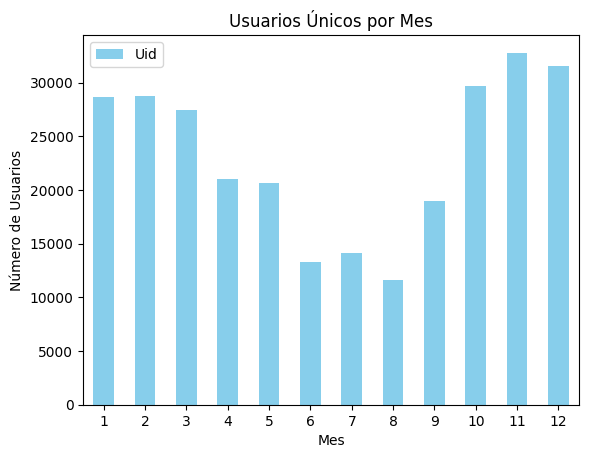

In [33]:
plt.figure(figsize=(10, 6))
users_per_month.plot(kind='bar', color='skyblue')
plt.title('Usuarios Únicos por Mes')
plt.xlabel('Mes')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=0)
plt.show()

De acuerdo a la grafica, el mes de noviembre sin duda es el que mayor visitas tuvo de usuarios unicos, junto con noviembre. Es un hecho que por alrededor de esas fechas los eventos son mas constantes por las fiestas que se celebran previas a año nuevo y navidad.

In [34]:
print("Visitas de usuarios unicos por semana")
users_per_week.head(10)

Visitas de usuarios unicos por semana


,Uid
week,
1,6918
2,6703
3,6972
4,7060
5,8111
6,7908
7,7759
8,7518
9,7395


<Figure size 1500x800 with 0 Axes>

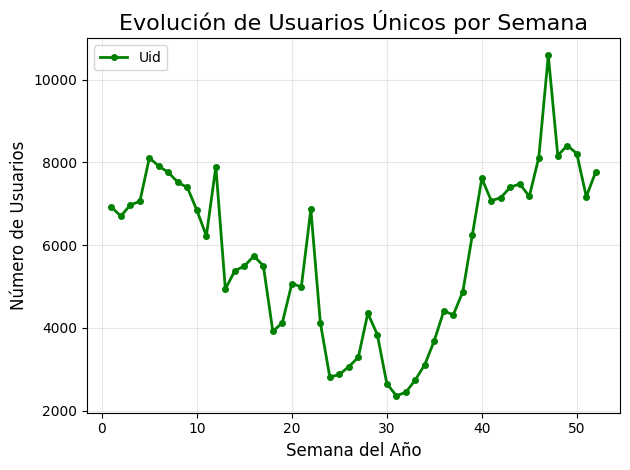

In [35]:
plt.figure(figsize=(15, 8))
users_per_week.plot(kind='line', marker='o', color='green', linewidth=2, markersize=4)
plt.title('Evolución de Usuarios Únicos por Semana', fontsize=16)
plt.xlabel('Semana del Año', fontsize=12)
plt.ylabel('Número de Usuarios', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se aprecia como destacan las semanas cerca de fin de año, como se determino anteriormente con la grafica usaruios unicos por mes. Predominan las fechas finales previas a año nuevo.

In [36]:
print("Visitas de usuarios unicos por dia")
users_per_day

Visitas de usuarios unicos por dia


,Uid
date,
2017-06-01,605
2017-06-02,608
2017-06-03,445
2017-06-04,476
2017-06-05,820
...,...
2018-05-27,620
2018-05-28,1039
2018-05-29,948


In [37]:
#¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [38]:
sessions_per_day = visits.groupby("date").agg({"Start Ts": "count"})

print("Sesiones de visita por dia")
sessions_per_day

Sesiones de visita por dia


,Start Ts
date,
2017-06-01,664
2017-06-02,658
2017-06-03,477
2017-06-04,510
2017-06-05,893
...,...
2018-05-27,672
2018-05-28,1156
2018-05-29,1035


In [39]:
#¿Cuál es la duración de cada sesión?

In [40]:
visits["Duration Ts"] = visits["End Ts"] - visits["Start Ts"]
visits["Duration Ts"] = visits["Duration Ts"].dt.total_seconds() / 60 

In [41]:
asl = visits["Duration Ts"].mean()
print("ASL (Avergae Session Lenght)")
asl

ASL (Avergae Session Lenght)


10.717094787608978

In [42]:
visits["Duration Ts"].describe()

count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: Duration Ts, dtype: float64

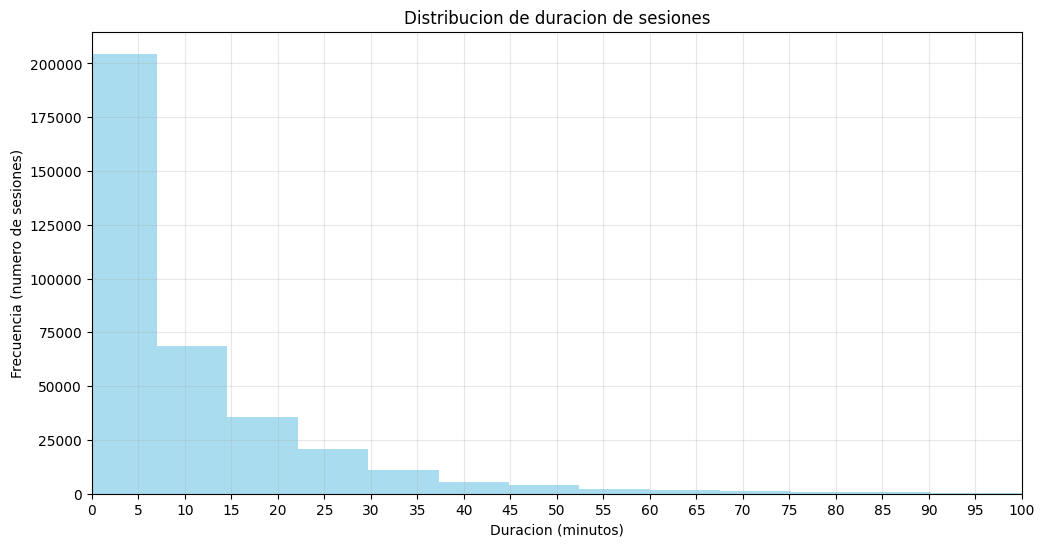

In [43]:
plt.figure(figsize=(12, 6))
plt.hist(visits["Duration Ts"], bins=100, color='skyblue', alpha=0.7)

plt.title('Distribucion de duracion de sesiones')
plt.xlabel('Duracion (minutos)')
plt.ylabel('Frecuencia (numero de sesiones)')
plt.xlim(0, 100)
plt.xticks(range(0, 101, 5))
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
print(f"Numero de sesiones con duracion negativa: {len(visits[visits['Duration Ts'] < 0])}")

Numero de sesiones con duracion negativa: 2


Las sesiones de visita que mas se repiten son las que duraron menos minutos, mas especificamente, las sesiones que duraron menos fueron de entre 0 y 7 minutos aproximadamente. Hay valores maximos muy alejados de la media, lo cual sesga los datos hacia la derecha y perjudica la media, ya que incrementa su valor por estos valores tan altos de usuarios que pasaron demasiado tiempo en una sesion. El valor minimo es negativo, no se considera justo porque no hay sesiones negativas. Existen 2 valores asi, por lo que no perjudica los datos como para quitarlos.

In [45]:
#¿Con qué frecuencia los usuarios regresan?

In [46]:
combined_per_day = users_per_day.join(sessions_per_day, on="date")

print("Sesiones de usuarios unicos y sesiones totales por dia")
combined_per_day

Sesiones de usuarios unicos y sesiones totales por dia


,Uid,Start Ts
date,,
2017-06-01,605,664
2017-06-02,608,658
2017-06-03,445,477
2017-06-04,476,510
2017-06-05,820,893
...,...,...
2018-05-27,620,672
2018-05-28,1039,1156
2018-05-29,948,1035


In [47]:
combined_per_day["sessions_per_user"] = combined_per_day["Start Ts"] / combined_per_day["Uid"]

print("Promedio de sesiones por usuario unico por dia")
combined_per_day

Promedio de sesiones por usuario unico por dia


,Uid,Start Ts,sessions_per_user
date,,,
2017-06-01,605,664,1.097521
2017-06-02,608,658,1.082237
2017-06-03,445,477,1.071910
2017-06-04,476,510,1.071429
2017-06-05,820,893,1.089024
...,...,...,...
2018-05-27,620,672,1.083871
2018-05-28,1039,1156,1.112608
2018-05-29,948,1035,1.091772


In [48]:
visits_per_user = visits.groupby("Uid").agg({"Start Ts": "count"})
visits_per_user = visits_per_user[visits_per_user["Start Ts"] > 1]

print("Usuarios agrupados por mas de una sesion")
visits_per_user

Usuarios agrupados por mas de una sesion


,Start Ts
Uid,
313578113262317,3
325320750514679,2
526778907996220,4
577434573913691,2
1260655184775459,4
...,...
18445884613277162497,3
18446104389491815722,2
18446156210226471712,7


In [49]:
total_users = visits["Uid"].nunique()
returning_users = len(visits_per_user)
return_rate = (returning_users / total_users) * 100

print("La frecuencia del total de usuarios unicos que regresan al sitio:")
return_rate

La frecuencia del total de usuarios unicos que regresan al sitio:


22.84622363248294

- 52,128 usuarios de un total de 228,283 usuarios únicos regresan
- El promedio de sesiones por usuario por día es muy bajo (~1.07-1.13)

In [50]:
#VENTAS
#¿Cuándo empieza la gente a comprar? 

In [51]:
orders

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247


In [52]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [53]:
first_orders = orders.groupby("Uid")["Buy Ts"].min()
first_orders.name = "first_purchase"
orders = orders.join(first_orders, on="Uid")

orders.head()

,Buy Ts,Revenue,Uid,first_purchase
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00


In [54]:
first_purchase = orders.groupby("Uid")["Buy Ts"].min().reset_index()
first_purchase.columns = ["Uid", "first_purchase"]
first_purchase

,Uid,first_purchase
0,313578113262317,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 18:33:00
3,2464366381792757,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00
...,...,...
36518,18445147675727495770,2017-11-24 09:03:00
36519,18445407535914413204,2017-09-22 23:55:00
36520,18445601152732270159,2018-03-26 22:54:00
36521,18446156210226471712,2018-02-18 19:34:00


In [55]:
first_sess = visits.groupby("Uid")["Start Ts"].min()
first_sess.name = "first sess"
visits = visits.join(first_sess, on="Uid")

visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,month,week,date,Duration Ts,first sess
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,12,51,2017-12-20,18.0,2017-12-20 17:20:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2,8,2018-02-19,28.0,2018-02-19 16:53:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,7,26,2017-07-01,0.0,2017-07-01 01:54:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20,24.0,2018-03-09 20:05:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,12,52,2017-12-27,0.0,2017-12-27 14:06:00


In [56]:
first_session = visits.groupby("Uid")["first sess"].first().reset_index()

first_session.head()

,Uid,first sess
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [57]:
conversion_data = first_session.merge(first_purchase, on="Uid", how="left")

conversion_data.head()

,Uid,first sess,first_purchase
0,11863502262781,2018-03-01 17:27:00,NaT
1,49537067089222,2018-02-06 15:55:00,NaT
2,297729379853735,2017-06-07 18:47:00,NaT
3,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
4,325320750514679,2017-09-30 14:29:00,NaT


In [58]:
conversion_data["days_to_conversion"] = (conversion_data["first_purchase"] - conversion_data["first sess"]).dt.days

conversion_data

,Uid,first sess,first_purchase,days_to_conversion
0,11863502262781,2018-03-01 17:27:00,NaT,NaN
1,49537067089222,2018-02-06 15:55:00,NaT,NaN
2,297729379853735,2017-06-07 18:47:00,NaT,NaN
3,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0
4,325320750514679,2017-09-30 14:29:00,NaT,NaN
...,...,...,...,...
228164,18446403737806311543,2017-11-30 03:36:00,NaT,NaN
228165,18446424184725333426,2017-12-06 20:32:00,NaT,NaN
228166,18446556406699109058,2018-01-01 16:29:00,NaT,NaN
228167,18446621818809592527,2017-12-27 13:27:00,NaT,NaN


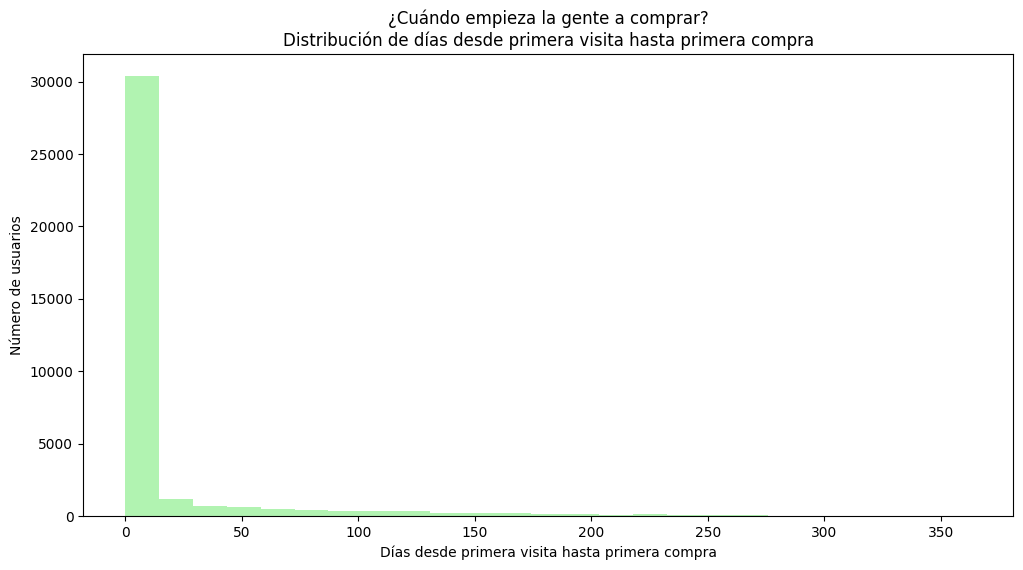

In [59]:
plt.figure(figsize=(12, 6))

plt.hist(conversion_data["days_to_conversion"], bins=25, color='lightgreen', alpha=0.7)

plt.title('¿Cuándo empieza la gente a comprar?\nDistribución de días desde primera visita hasta primera compra')
plt.xlabel('Días desde primera visita hasta primera compra')
plt.ylabel('Número de usuarios')

plt.show()

In [60]:
conversion_data["days_to_conversion"].describe()

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: days_to_conversion, dtype: float64

Mediante el analisis de frecuencia con la que cada usuario compra de acuerdo al tiempo de su primera visita destaca que la mayoria de los usuarios (75%) realizan su compra 2 dias o menos despues de su primera visita al sitio y la mitad de los usuarios (50%) compran el mismo dia que hacen su visita al sitio, por lo que se puede deducir que si la mitad de la gente compra en el mismo dia que visitan la pagina, es porque esta bien estructurada para llevar a cabo la compra.

In [61]:
def categorizar_conversion(dias):
    if dias == 0:
        return 'Conversion 0d'
    elif dias == 1:
        return 'Conversion 1d'
    elif dias <= 7:
        return 'Conversion 1-7d'
    elif dias <= 30:
        return 'Conversion 8-30d'
    else:
        return 'Conversion 30+d'

conversion_data['categorie_conversion'] = conversion_data["days_to_conversion"].apply(categorizar_conversion)

In [62]:
conversion_data

,Uid,first sess,first_purchase,days_to_conversion,categorie_conversion
0,11863502262781,2018-03-01 17:27:00,NaT,NaN,Conversion 30+d
1,49537067089222,2018-02-06 15:55:00,NaT,NaN,Conversion 30+d
2,297729379853735,2017-06-07 18:47:00,NaT,NaN,Conversion 30+d
3,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106.0,Conversion 30+d
4,325320750514679,2017-09-30 14:29:00,NaT,NaN,Conversion 30+d
...,...,...,...,...,...
228164,18446403737806311543,2017-11-30 03:36:00,NaT,NaN,Conversion 30+d
228165,18446424184725333426,2017-12-06 20:32:00,NaT,NaN,Conversion 30+d
228166,18446556406699109058,2018-01-01 16:29:00,NaT,NaN,Conversion 30+d
228167,18446621818809592527,2017-12-27 13:27:00,NaT,NaN,Conversion 30+d


In [63]:
conversion_data["categorie_conversion"].value_counts()

Conversion 30+d     196548
Conversion 0d        26363
Conversion 8-30d      2178
Conversion 1-7d       2069
Conversion 1d         1011
Name: categorie_conversion, dtype: int64

In [64]:
conversion_summary = conversion_data["categorie_conversion"].value_counts(normalize=True) * 100
print(conversion_summary)

Conversion 30+d     86.141413
Conversion 0d       11.554155
Conversion 8-30d     0.954556
Conversion 1-7d      0.906784
Conversion 1d        0.443093
Name: categorie_conversion, dtype: float64


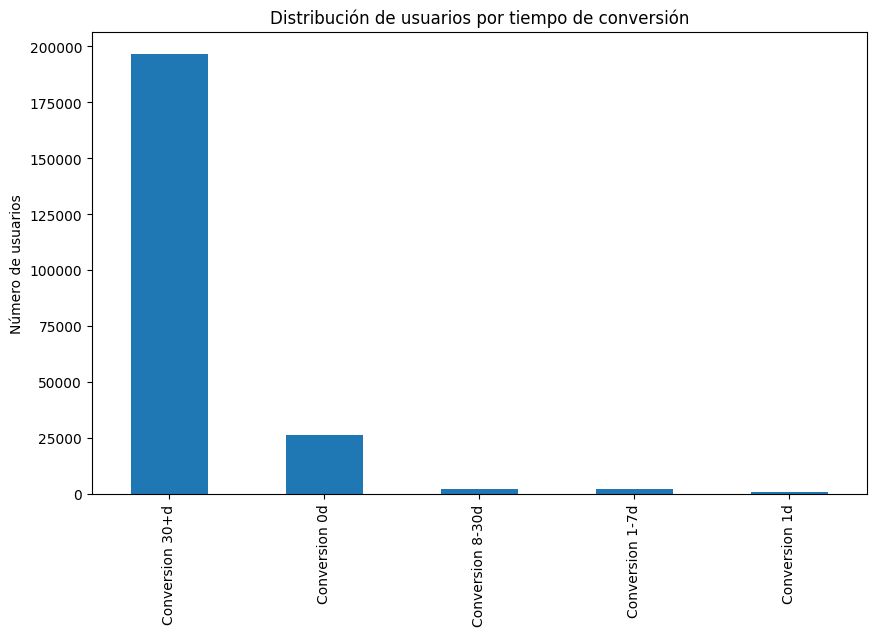

In [65]:
plt.figure(figsize=(10, 6))
conversion_data["categorie_conversion"].value_counts().plot(kind='bar')
plt.title('Distribución de usuarios por tiempo de conversión')
plt.ylabel('Número de usuarios')
plt.show()

La pregunta relevante de cuando empieza a comprar cada cliente se responde con las graficas previas y despues del plantamiento de esta misma pregunta en el codigo previo a estas graficas. 

In [66]:
#¿Cuántos pedidos hacen durante un período de tiempo dado?

In [67]:
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,month,week,date,Duration Ts,first sess
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,12,51,2017-12-20,18.0,2017-12-20 17:20:00
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2,8,2018-02-19,28.0,2018-02-19 16:53:00
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,7,26,2017-07-01,0.0,2017-07-01 01:54:00
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20,24.0,2018-03-09 20:05:00
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,12,52,2017-12-27,0.0,2017-12-27 14:06:00


In [68]:
orders.head()

,Buy Ts,Revenue,Uid,first_purchase
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00


In [69]:
orders["purchase_month"] = orders["Buy Ts"].astype("datetime64[M]")
orders

,Buy Ts,Revenue,Uid,first_purchase,purchase_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01
...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31 23:50:00,2018-05-01
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31 23:50:00,2018-05-01
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31 23:54:00,2018-05-01
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2018-05-01


In [70]:
orders["purchase_month"].describe()

count                   50415
unique                     13
top       2017-12-01 00:00:00
freq                     6218
first     2017-06-01 00:00:00
last      2018-06-01 00:00:00
Name: purchase_month, dtype: object

In [71]:
purchase_by_user = orders.groupby("Uid")["Buy Ts"].count().reset_index()
purchase_by_user

,Uid,Buy Ts
0,313578113262317,1
1,1575281904278712,2
2,2429014661409475,1
3,2464366381792757,1
4,2551852515556206,2
...,...,...
36518,18445147675727495770,1
36519,18445407535914413204,3
36520,18445601152732270159,1
36521,18446156210226471712,1


In [72]:
purchases_by_month = orders.groupby("purchase_month")["Buy Ts"].count()

print("Registros de compras por mes")
purchases_by_month

Registros de compras por mes


purchase_month
2017-06-01    2354
2017-07-01    2363
2017-08-01    1807
2017-09-01    3387
2017-10-01    5679
2017-11-01    5659
2017-12-01    6218
2018-01-01    4721
2018-02-01    5281
2018-03-01    5326
2018-04-01    3273
2018-05-01    4346
2018-06-01       1
Name: Buy Ts, dtype: int64

In [73]:
users_purchase_month = orders.groupby("purchase_month")["Uid"].nunique()

print("Numero de usuarios unicos por mes de compra")
users_purchase_month

Numero de usuarios unicos por mes de compra


purchase_month
2017-06-01    2023
2017-07-01    1984
2017-08-01    1472
2017-09-01    2750
2017-10-01    4675
2017-11-01    4547
2017-12-01    4942
2018-01-01    3898
2018-02-01    4258
2018-03-01    4181
2018-04-01    2744
2018-05-01    3544
2018-06-01       1
Name: Uid, dtype: int64

In [74]:
avg_orders_per_user_month = purchases_by_month / users_purchase_month

print("Promedio de compra por usuario por mes")
avg_orders_per_user_month

Promedio de compra por usuario por mes


purchase_month
2017-06-01    1.163618
2017-07-01    1.191028
2017-08-01    1.227582
2017-09-01    1.231636
2017-10-01    1.214759
2017-11-01    1.244557
2017-12-01    1.258195
2018-01-01    1.211134
2018-02-01    1.240254
2018-03-01    1.273858
2018-04-01    1.192784
2018-05-01    1.226298
2018-06-01    1.000000
dtype: float64

In [75]:
avg_orders_per_user_month.mean()

1.2058233446244648

**El resultado 1.2058233446244648 significa que en promedio, durante todo el período analizado, cada usuario realizó aproximadamente 1.21 órdenes por mes.**

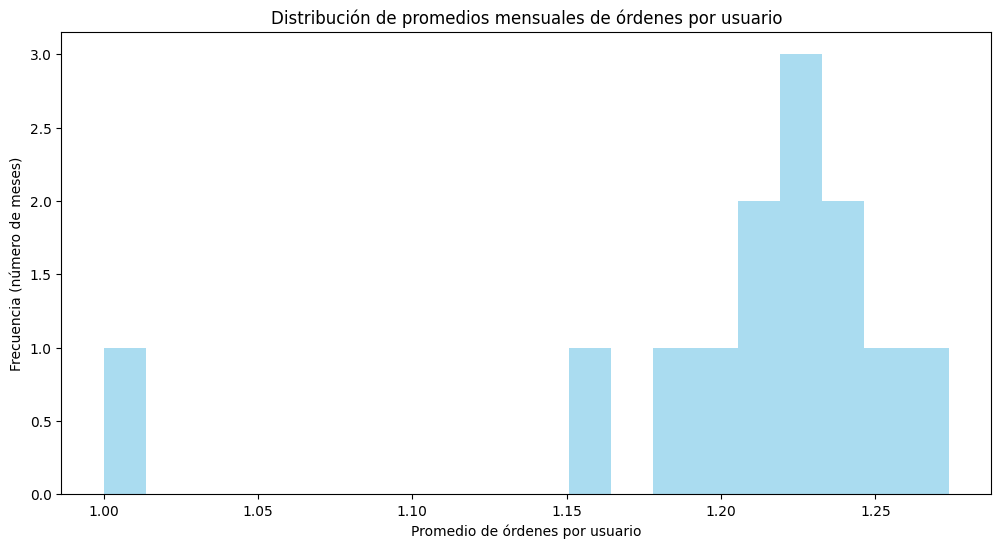

In [76]:

plt.figure(figsize=(12, 6))
plt.hist(avg_orders_per_user_month, bins=20, color='skyblue', alpha=0.7)
plt.title('Distribución de promedios mensuales de órdenes por usuario')
plt.xlabel('Promedio de órdenes por usuario')
plt.ylabel('Frecuencia (número de meses)')
plt.show()

In [77]:
#¿Cuál es el tamaño promedio de compra?

In [78]:
orders.head()

,Buy Ts,Revenue,Uid,first_purchase,purchase_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01


In [79]:
print(f"Promedio de ingreso de todas las compras: {orders['Revenue'].mean()}")

Promedio de ingreso de todas las compras: 4.999646930477041


In [80]:
#¿Cuánto dinero traen? (LTV)

In [81]:
ltv_by_user = orders.groupby("Uid").agg({"Revenue": "sum"})
ltv_by_user

,Revenue
Uid,
313578113262317,0.55
1575281904278712,3.05
2429014661409475,73.33
2464366381792757,2.44
2551852515556206,10.99
...,...
18445147675727495770,3.05
18445407535914413204,0.88
18445601152732270159,4.22


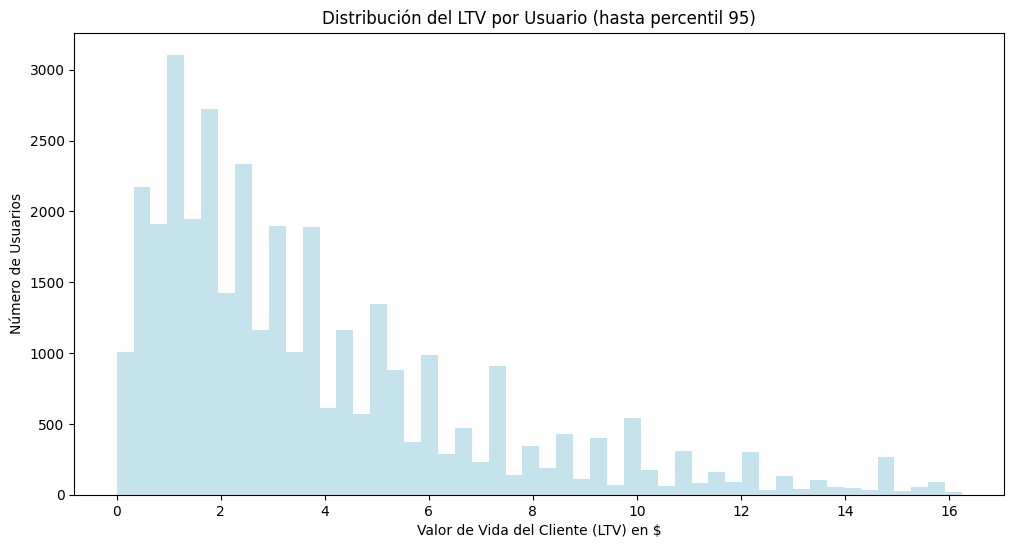

In [82]:

plt.figure(figsize=(12, 6))
percentil_95 = ltv_by_user['Revenue'].quantile(0.95)
plt.hist(ltv_by_user['Revenue'], bins=50, range=(0, percentil_95), color='lightblue', alpha=0.7)
plt.title('Distribución del LTV por Usuario (hasta percentil 95)')
plt.xlabel('Valor de Vida del Cliente (LTV) en $')
plt.ylabel('Número de Usuarios')
plt.show()


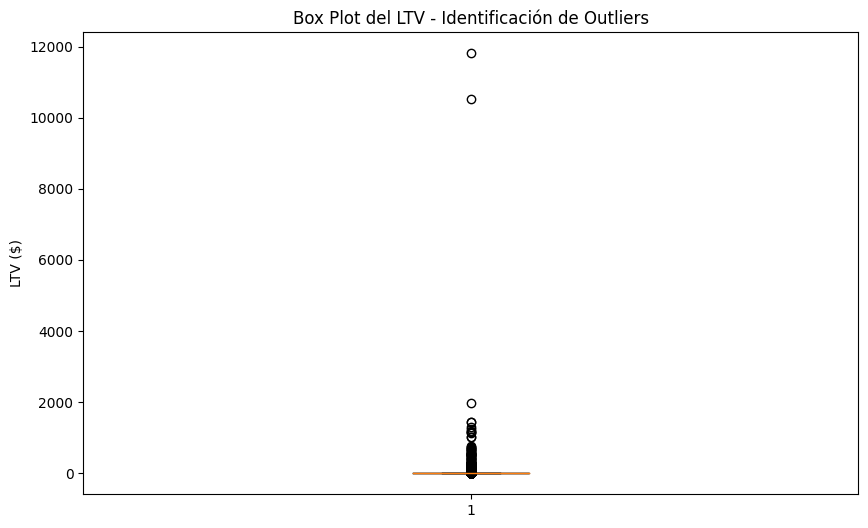

In [83]:
plt.figure(figsize=(10, 6))
plt.boxplot(ltv_by_user['Revenue'])
plt.title('Box Plot del LTV - Identificación de Outliers')
plt.ylabel('LTV ($)')
plt.show()

In [84]:
ltv_by_user.describe()

,Revenue
count,36523.000000
mean,6.901328
std,88.128535
min,0.000000
25%,1.470000
50%,3.050000
75%,5.800000
max,11810.180000


Mediante los resultados de estos dos graficos y las tablas se responde a la pregunta de cuanto dinero aporta cada cliente y cual fue la frecuencia de aportacion por cliente. Se aprecia que hay valores muy altos/atipicos (clientes que gastaron demasiado en pedidos), la frecuencia mas alta, como valor maximo es de 11810 dolares que un cliente o mas de uno aporto a la compañia. Esto sesga los datos a la derecha y perjudica el promedio, ya que los datos se concentran mas entre 1.47 y 5.80 dolares (entre 25% y 75% de los datos) y el promedio de aportacion de ingreso por usuario es de 6.9 y la mediana es de 3.05 dolares, por lo que es destacable que por los valores atipicos el promedio/media cambia y se vuelve mas grande, sesga a la derecha.

In [85]:
#Marketing:
#1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo)
#2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [86]:
costs.describe()

,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [87]:
print(f"Gasto total de costo de adquisicion de clientes: {costs['costs'].sum()}")

Gasto total de costo de adquisicion de clientes: 329131.62


In [88]:
print("Gastos por fuente de adquisicion")
gastos_por_fuente = costs.groupby('source_id')['costs'].sum().reset_index()
gastos_por_fuente

Gastos por fuente de adquisicion


,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


<Figure size 1000x600 with 0 Axes>

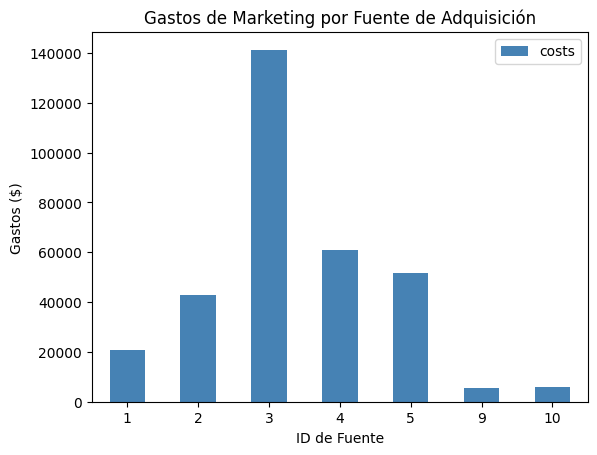

In [89]:
plt.figure(figsize=(10, 6))
gastos_por_fuente.plot(x='source_id', y='costs', kind='bar', color='steelblue')
plt.title('Gastos de Marketing por Fuente de Adquisición')
plt.xlabel('ID de Fuente')
plt.ylabel('Gastos ($)')
plt.xticks(rotation=0)
plt.show()

In [90]:
print("Gastos a lo largo del tiempo (por mes)")
costs['mes'] = costs['dt'].dt.to_period('M')
gastos_mensuales = costs.groupby(costs['dt'].dt.to_period('M'))['costs'].sum().reset_index()
gastos_mensuales

Gastos a lo largo del tiempo (por mes)


,dt,costs
0,2017-06,18015.00
1,2017-07,18240.59
2,2017-08,14790.54
3,2017-09,24368.91
4,2017-10,36322.88
5,2017-11,37907.88
6,2017-12,38315.35
7,2018-01,33518.52
8,2018-02,32723.03
9,2018-03,30415.27


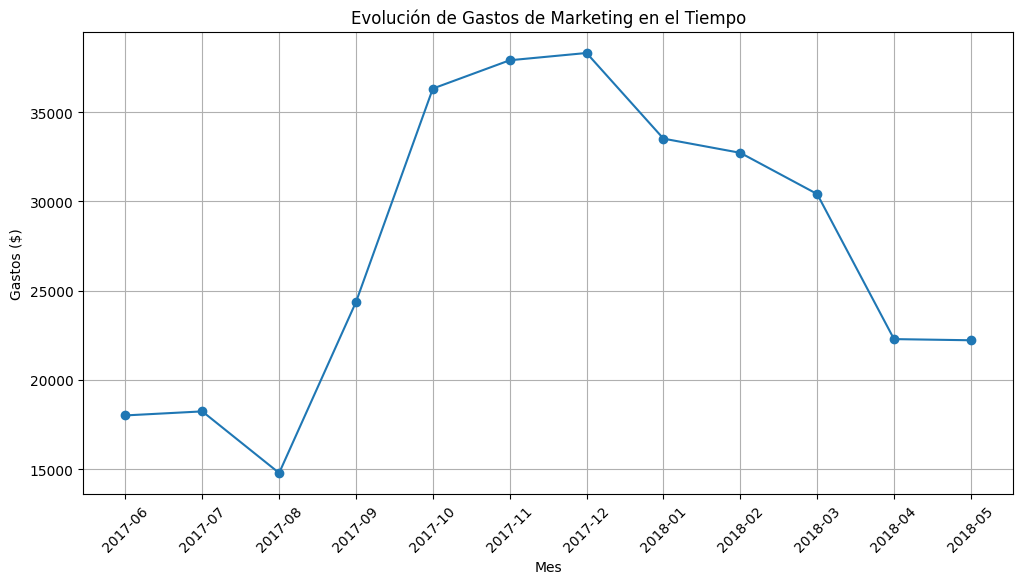

In [91]:
plt.figure(figsize=(12, 6))
plt.plot(gastos_mensuales["dt"].astype(str), gastos_mensuales["costs"], marker='o')
plt.title('Evolución de Gastos de Marketing en el Tiempo')
plt.xlabel('Mes')
plt.ylabel('Gastos ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

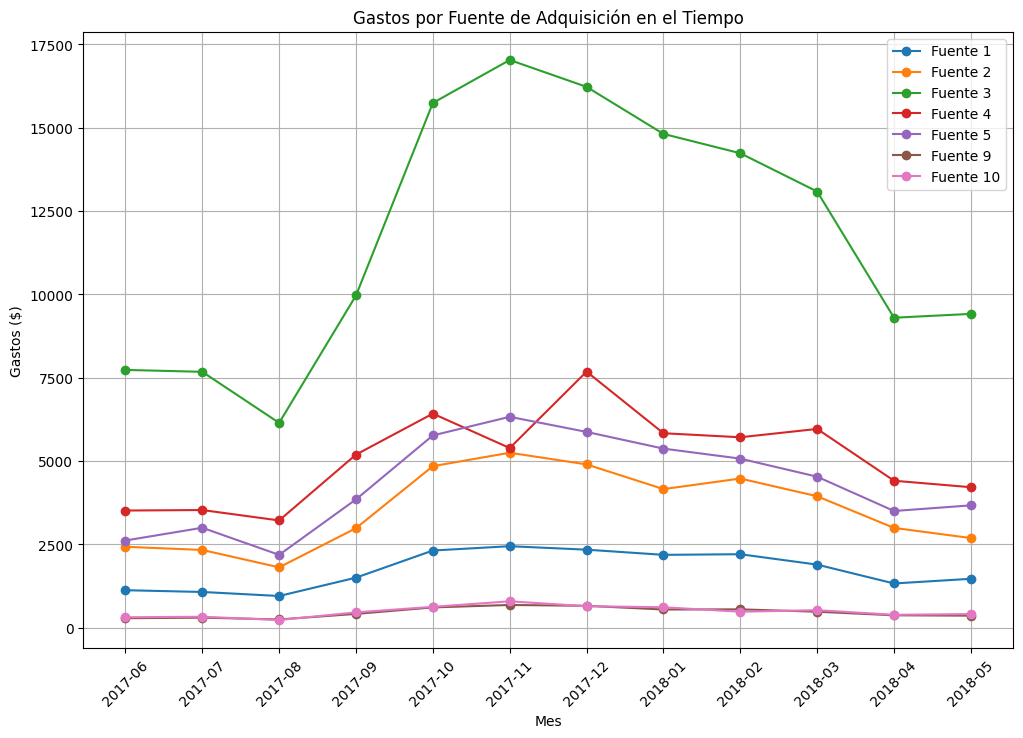

In [92]:
plt.figure(figsize=(12, 8))
for source in costs['source_id'].unique():
    data_source = costs[costs['source_id'] == source]
    monthly_data = data_source.groupby(data_source['dt'].dt.to_period('M'))['costs'].sum()
    plt.plot(monthly_data.index.astype(str), monthly_data.values, 
             marker='o', label=f'Fuente {source}')

plt.title('Gastos por Fuente de Adquisición en el Tiempo')
plt.xlabel('Mes')
plt.ylabel('Gastos ($)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

La grafica determina que la fuente de adquisicion (source_id) 3 es la que predomina destacablemente en comparacion a las otras fuentes en cuanto a gastos de marketing se refiere. Seguramente por ser una fuente de adquisicion rentable es porque le invirtieron mas dinero. El mes que mas invirtieron para obtencion de clientes fue en diciembre de 2017 de acuerdo a las todas las fuentes de adquisicion en general, la estacionalidad afecta indudablemente como para que los encargados de marketing desarrollen las campañas publicitarias necesarias para el los ultimos meses del año y la gente se anime mas a visitar y/o hacer compras. 

Cabe aclarar que hay fuentes de adquisicion que hacen falta. Son las fuentes 6,7 y 8 de la columna "Source Id". No hay inversion/gastos asignados referentes de estas fuentes de adquisicion.

In [93]:
# 3. ¿Cuán rentables eran las inversiones? (ROMI)

In [94]:
fusion_definitiva = visits.merge(orders, on="Uid")
fusion_definitiva.head()

,Device,End Ts,Source Id,Start Ts,Uid,month,week,date,Duration Ts,first sess,Buy Ts,Revenue,first_purchase,purchase_month
0,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20,24.0,2018-03-09 20:05:00,2018-03-09 20:25:00,2.33,2018-03-09 20:25:00,2018-03-01
1,desktop,2018-03-09 20:33:00,4,2018-03-09 20:05:00,16174680259334210214,3,10,2018-03-09,28.0,2018-03-09 20:05:00,2018-03-09 20:25:00,2.33,2018-03-09 20:25:00,2018-03-01
2,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,9,35,2017-09-03,1.0,2017-09-03 21:35:00,2017-09-04 12:46:00,2.44,2017-09-04 12:46:00,2017-09-01
3,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,9,35,2017-09-03,1.0,2017-09-03 21:35:00,2017-10-28 00:01:00,1.53,2017-09-04 12:46:00,2017-10-01
4,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,9,35,2017-09-03,1.0,2017-09-03 21:35:00,2017-10-28 19:16:00,1.53,2017-09-04 12:46:00,2017-10-01


In [95]:
fusion_definitiva["purchase_month"] = fusion_definitiva["purchase_month"].dt.month

In [96]:
fusion_definitiva_1 = fusion_definitiva.groupby(["Source Id", "purchase_month"])["Revenue"].sum().reset_index()
fusion_definitiva_1

,Source Id,purchase_month,Revenue
0,1,1,138532.86
1,1,2,195325.46
2,1,3,323459.54
3,1,4,292377.87
4,1,5,150728.27
...,...,...,...
80,10,8,625.29
81,10,9,667.19
82,10,10,1360.70
83,10,11,1622.45


In [97]:
costs.columns = ["Source Id", "dt", "costs", "mes"]
costs.head()

,Source Id,dt,costs,mes
0,1,2017-06-01,75.20,2017-06
1,1,2017-06-02,62.25,2017-06
2,1,2017-06-03,36.53,2017-06
3,1,2017-06-04,55.00,2017-06
4,1,2017-06-05,57.08,2017-06


In [98]:
costs_1 = costs.groupby(["Source Id", "mes"])["costs"].sum().reset_index()
costs_1['mes (numero)'] = costs_1['mes'].dt.month
costs_1

,Source Id,mes,costs,mes (numero)
0,1,2017-06,1125.61,6
1,1,2017-07,1072.88,7
2,1,2017-08,951.81,8
3,1,2017-09,1502.01,9
4,1,2017-10,2315.75,10
...,...,...,...,...
79,10,2018-01,614.35,1
80,10,2018-02,480.88,2
81,10,2018-03,526.41,3
82,10,2018-04,388.25,4


In [99]:
costs_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   Source Id     84 non-null     int64    
 1   mes           84 non-null     period[M]
 2   costs         84 non-null     float64  
 3   mes (numero)  84 non-null     int64    
dtypes: float64(1), int64(2), period[M](1)
memory usage: 2.8 KB


In [100]:
fusion_completa = fusion_definitiva_1.merge(
    costs_1, left_on=['Source Id', 'purchase_month'], right_on=['Source Id', 'mes (numero)'], how='left')

fusion_completa

,Source Id,purchase_month,Revenue,mes,costs,mes (numero)
0,1,1,138532.86,2018-01,2186.18,1.0
1,1,2,195325.46,2018-02,2204.48,2.0
2,1,3,323459.54,2018-03,1893.09,3.0
3,1,4,292377.87,2018-04,1327.49,4.0
4,1,5,150728.27,2018-05,1467.61,5.0
...,...,...,...,...,...,...
80,10,8,625.29,2017-08,232.57,8.0
81,10,9,667.19,2017-09,460.67,9.0
82,10,10,1360.70,2017-10,627.24,10.0
83,10,11,1622.45,2017-11,792.36,11.0


In [101]:
fusion_completa.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype    
---  ------          --------------  -----    
 0   Source Id       85 non-null     int64    
 1   purchase_month  85 non-null     int64    
 2   Revenue         85 non-null     float64  
 3   mes             84 non-null     period[M]
 4   costs           84 non-null     float64  
 5   mes (numero)    84 non-null     float64  
dtypes: float64(3), int64(2), period[M](1)
memory usage: 4.6 KB


In [102]:
fusion_completa["Source Id"].value_counts()

1     12
2     12
3     12
4     12
5     12
9     12
10    12
7      1
Name: Source Id, dtype: int64

In [103]:
fusion_completa["ROMI"] = (fusion_completa["Revenue"] / fusion_completa["costs"]) * 100
fusion_completa.head()

,Source Id,purchase_month,Revenue,mes,costs,mes (numero),ROMI
0,1,1,138532.86,2018-01,2186.18,1.0,6336.754522
1,1,2,195325.46,2018-02,2204.48,2.0,8860.387030
2,1,3,323459.54,2018-03,1893.09,3.0,17086.326588
3,1,4,292377.87,2018-04,1327.49,4.0,22024.864217
4,1,5,150728.27,2018-05,1467.61,5.0,10270.321816


In [104]:
pivot_revenue = fusion_completa.pivot_table(
        index="Source Id",
        columns="purchase_month",
        values= "Revenue"
)

pivot_costs = fusion_completa.pivot_table(
    values='costs', 
    index='Source Id', 
    columns='purchase_month', 
    aggfunc='sum'
)

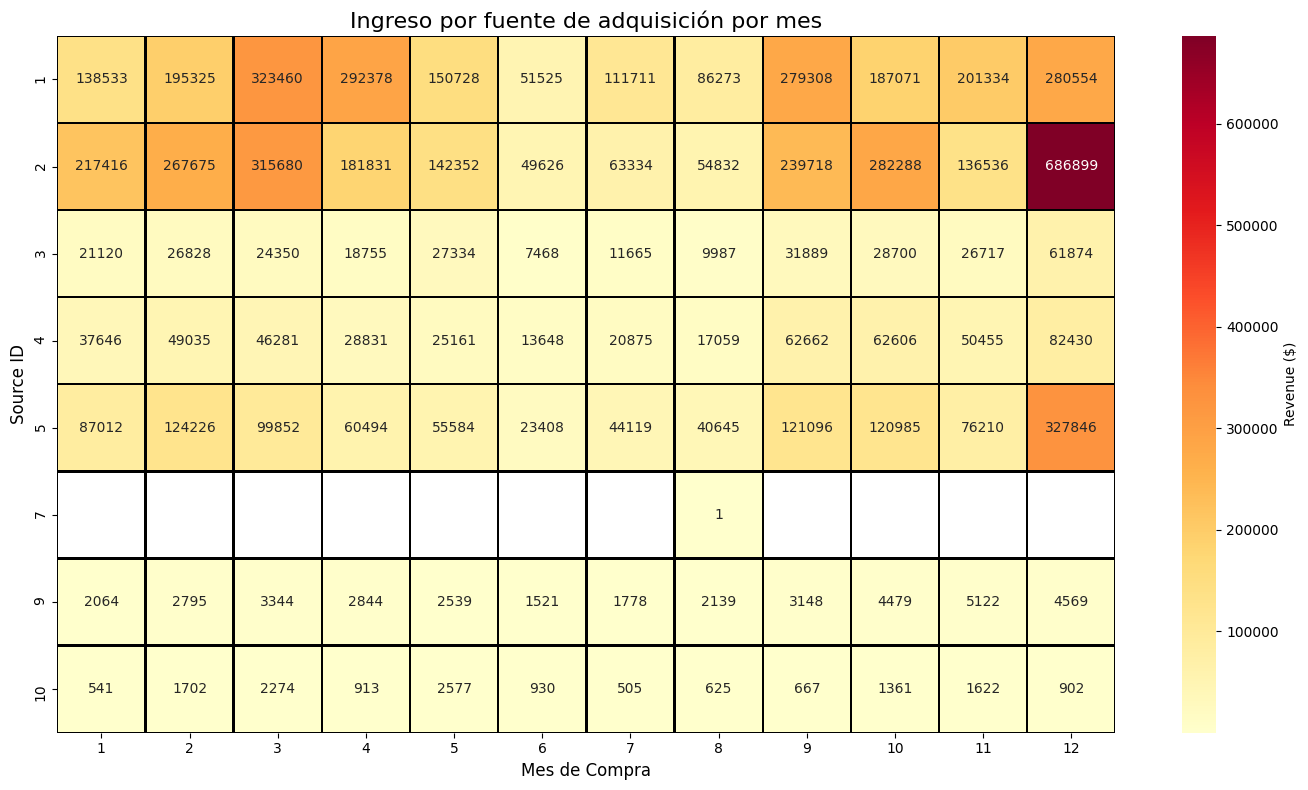

In [105]:
plt.figure(figsize=(14, 8))

sns.heatmap(pivot_revenue, 
            annot=True,          
            fmt='.0f',           
            cmap='YlOrRd',        
            cbar_kws={'label': 'Revenue ($)'},
            linewidths=1,
            linecolor="black")

plt.title('Ingreso por fuente de adquisición por mes', fontsize=16)
plt.xlabel('Mes de Compra', fontsize=12)
plt.ylabel('Source ID', fontsize=12)
plt.tight_layout()
plt.show()

Es muy notable los colores mas oscuros del ingreso total por mes que tuvieron los usuarios que provienen de las fuentes de informacion (Source Id) "2" y "1". Fueron los usuarios que aportaron mas ingresos a la compañia. La fuente de adquisicion (Source Id) "7" no tiene establecido ingreso por ninguno de los meses, hay valores ausentes de ingreso por parte de esta fuente, por eso no aparecen datos respecto a la misma.

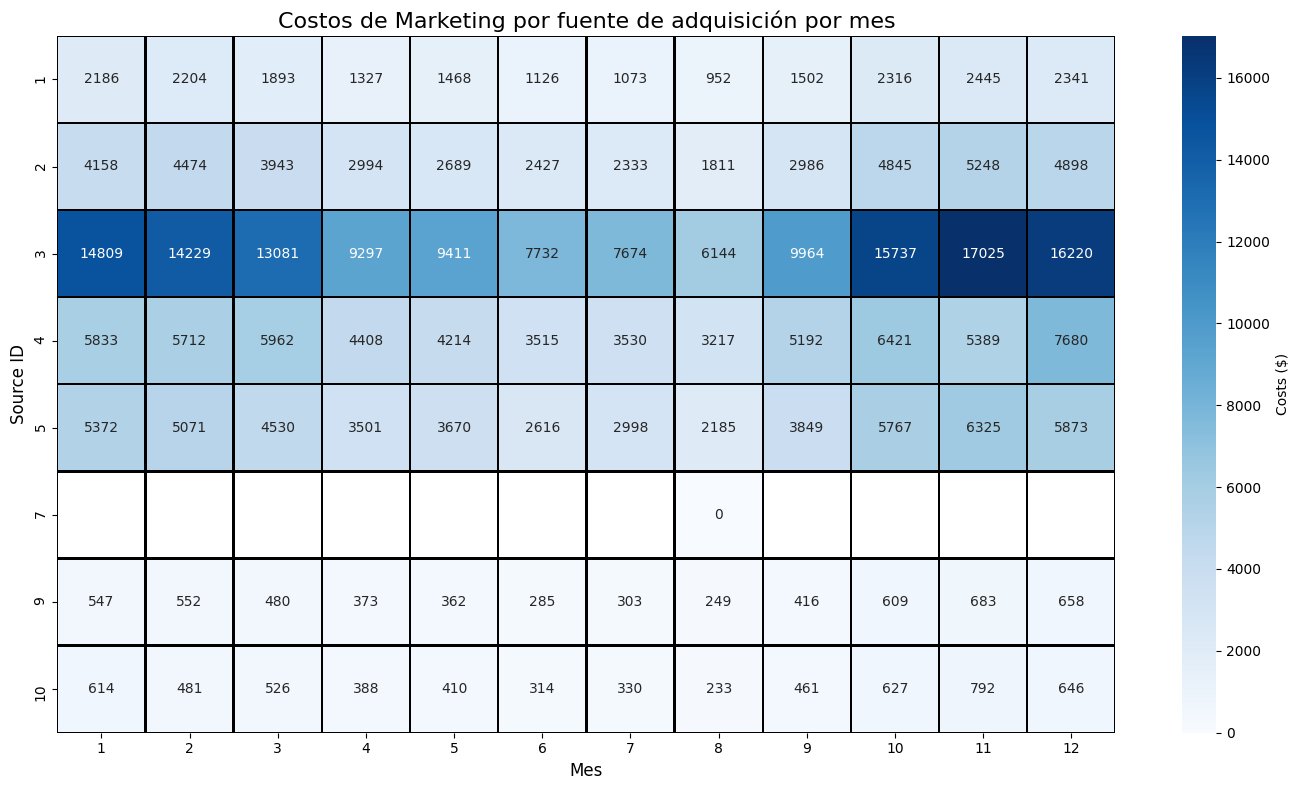

In [106]:
plt.figure(figsize=(14, 8))

# Crear el heatmap para costs
sns.heatmap(pivot_costs, 
            annot=True,           
            fmt='.0f',           
            cmap='Blues',        
            cbar_kws={'label': 'Costs ($)'},
            linewidths=1,
            linecolor="black")

plt.title('Costos de Marketing por fuente de adquisición por mes', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Source ID', fontsize=12)
plt.tight_layout()
plt.show()

Por lo visto en la grafica de ingreso por fuente de adquisicion por mes, la fuente "3" no tiene ingresos altos en comparacion a otras fuentes de adquisicion. Sin embargo es a la que mas se le ha invertido en costos de marketing. Parece ser que en cuanto a las fuentes de adquisicion "4", "5" se les invirtio lo necesario para tener buen retorno de inversion.

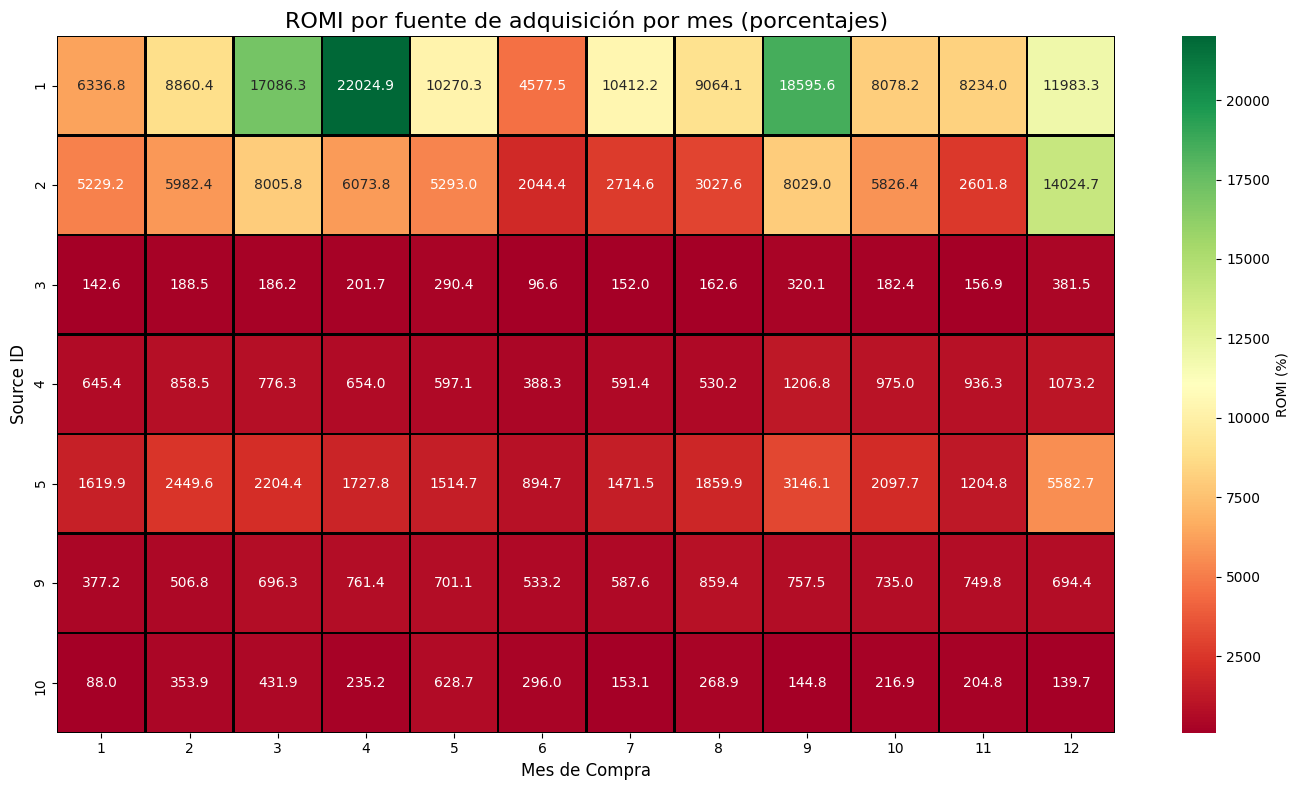

In [107]:
pivot_romi = fusion_completa.pivot_table(
    values='ROMI',
    index='Source Id',
    columns='purchase_month',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))

sns.heatmap(pivot_romi, 
            annot=True,           
            fmt='.1f',           
            cmap='RdYlGn',        
            cbar_kws={'label': 'ROMI (%)'},
            linewidths=1,
            linecolor="black")

plt.title('ROMI por fuente de adquisición por mes (porcentajes)', fontsize=16)
plt.xlabel('Mes de Compra', fontsize=12)
plt.ylabel('Source ID', fontsize=12)
plt.tight_layout()
plt.show()

### TASA DE RETENCION

In [108]:
visits["first_sess_month"] = visits["first sess"].astype("datetime64[M]")
visits["sess_month"] = visits["Start Ts"].astype("datetime64[M]")

In [109]:
visits["cohort_lifetime"] = (visits["sess_month"] - visits["first_sess_month"])
visits["cohort_lifetime"] = visits["cohort_lifetime"] / np.timedelta64(1, 'M')
visits["cohort_lifetime"] = visits["cohort_lifetime"].astype(int)

In [110]:
visits.head()

,Device,End Ts,Source Id,Start Ts,Uid,month,week,date,Duration Ts,first sess,first_sess_month,sess_month,cohort_lifetime
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,12,51,2017-12-20,18.0,2017-12-20 17:20:00,2017-12-01,2017-12-01,0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2,8,2018-02-19,28.0,2018-02-19 16:53:00,2018-02-01,2018-02-01,0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,7,26,2017-07-01,0.0,2017-07-01 01:54:00,2017-07-01,2017-07-01,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,5,20,2018-05-20,24.0,2018-03-09 20:05:00,2018-03-01,2018-05-01,2
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,12,52,2017-12-27,0.0,2017-12-27 14:06:00,2017-12-01,2017-12-01,0


In [111]:
cohorts = visits.groupby(["first_sess_month", "cohort_lifetime"]).agg({"Uid": "nunique"}).reset_index()

In [112]:
cohorts

,first_sess_month,cohort_lifetime,Uid
0,2017-06-01,0,13259
1,2017-06-01,2,713
2,2017-06-01,3,814
3,2017-06-01,4,909
4,2017-06-01,5,947
...,...,...,...
58,2018-03-01,0,20589
59,2018-03-01,1,861
60,2018-03-01,2,557
61,2018-04-01,0,15709


In [113]:
cohorts[(cohorts["first_sess_month"] == "2017-06-01") & (cohorts["cohort_lifetime"] == 1)]

,first_sess_month,cohort_lifetime,Uid


Los usuarios de la cohort de "2017-06-01" no tuvieron actividad/sesiones durante su segundo mes de vida "cohort_lifetime". Al parecer hay un gap entre los datos de esta cohort en especifico porque literalmente no hay ni una sesion de esos usuarios en su segundo mes de vida que es el valor "1" de "cohort_lifetime".

In [114]:
initial_users = cohorts[cohorts["cohort_lifetime"] == 0][["first_sess_month", "Uid"]]

In [115]:
initial_users = initial_users.rename(columns={"Uid": "cohort_users"})

In [116]:
initial_users

,first_sess_month,cohort_users
0,2017-06-01,13259
10,2017-07-01,13140
19,2017-08-01,10181
28,2017-09-01,16704
34,2017-10-01,25977
41,2017-11-01,27248
46,2017-12-01,25268
51,2018-01-01,22624
55,2018-02-01,22197
58,2018-03-01,20589


In [117]:
cohorts = cohorts.merge(initial_users, on="first_sess_month")

In [118]:
cohorts["Retention"] = cohorts["Uid"] / cohorts["cohort_users"]

In [119]:
cohorts

,first_sess_month,cohort_lifetime,Uid,cohort_users,Retention
0,2017-06-01,0,13259,13259,1.000000
1,2017-06-01,2,713,13259,0.053775
2,2017-06-01,3,814,13259,0.061392
3,2017-06-01,4,909,13259,0.068557
4,2017-06-01,5,947,13259,0.071423
...,...,...,...,...,...
58,2018-03-01,0,20589,20589,1.000000
59,2018-03-01,1,861,20589,0.041818
60,2018-03-01,2,557,20589,0.027053
61,2018-04-01,0,15709,15709,1.000000


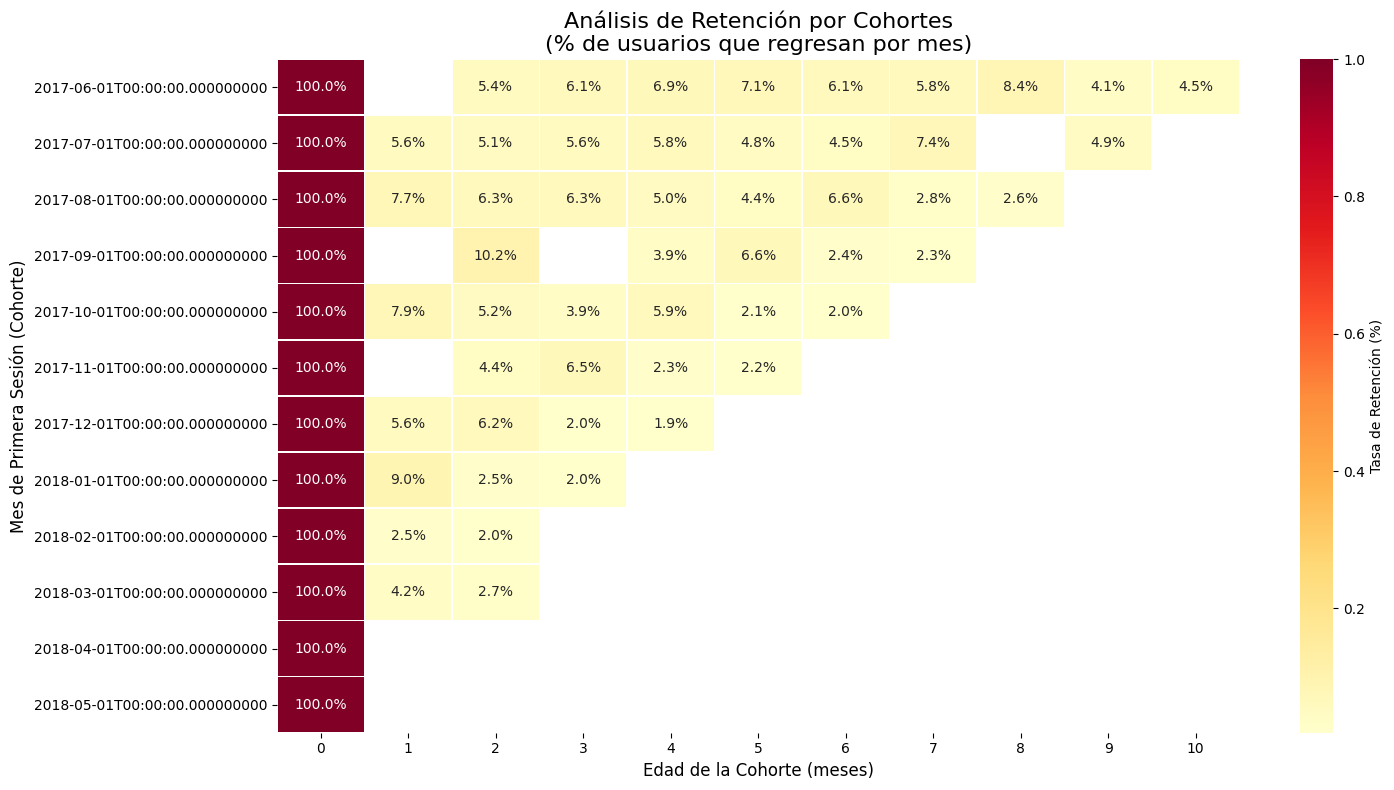

In [120]:
cohort_pivot = cohorts.pivot_table(
    values='Retention', 
    index='first_sess_month', 
    columns='cohort_lifetime'
)

plt.figure(figsize=(15, 8))
sns.heatmap(cohort_pivot, 
            annot=True, 
            fmt='.1%',  # formato porcentaje
            cmap='YlOrRd',
            cbar_kws={'label': 'Tasa de Retención (%)'},
            linewidths=0.5)
plt.title('Análisis de Retención por Cohortes\n(% de usuarios que regresan por mes)', fontsize=16)
plt.xlabel('Edad de la Cohorte (meses)', fontsize=12)
plt.ylabel('Mes de Primera Sesión (Cohorte)', fontsize=12)
plt.tight_layout()
plt.show()

Ninguna de las cohortes alcanzó tasas de retención aceptables para un e-commerce. La retención promedio en el primer mes es de apenas 4-5%, y continúa disminuyendo en meses posteriores. Esto indica problemas serios en la experiencia del usuario que requieren rediseño y mejoras integrales en la plataforma. Las métricas objetivo deberían apuntar a retenciones del 20-30% en el primer mes como mínimo para ser competitivos.

- La retención en el primer mes (edad 1) está alrededor del 4-5% para la mayoría de cohortes
- Para el segundo mes (edad 2) baja aún más, a aproximadamente 2-3%
- Algunas cohortes muestran ligeras mejoras en meses posteriores, pero siguen siendo muy bajas

### LFT (Life Time Value)

In [121]:
orders

,Buy Ts,Revenue,Uid,first_purchase,purchase_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01
...,...,...,...,...,...
50410,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31 23:50:00,2018-05-01
50411,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31 23:50:00,2018-05-01
50412,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31 23:54:00,2018-05-01
50413,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2018-05-01


In [122]:
orders = orders.rename(columns={"first_purchase": "first_purchase_M"})
orders["first_purchase_M"] = orders["first_purchase_M"].astype("datetime64[M]")

In [123]:
orders_cohorts = orders.groupby(["first_purchase_M", "purchase_month"]).agg({"Revenue": "sum"}).reset_index()
print("Ingreso total por cohort por mes de compra")
orders_cohorts

Ingreso total por cohort por mes de compra


,first_purchase_M,purchase_month,Revenue
0,2017-06-01,2017-06-01,9557.49
1,2017-06-01,2017-07-01,981.82
2,2017-06-01,2017-08-01,885.34
3,2017-06-01,2017-09-01,1931.30
4,2017-06-01,2017-10-01,2068.58
...,...,...,...
74,2018-03-01,2018-05-01,1114.87
75,2018-04-01,2018-04-01,10600.69
76,2018-04-01,2018-05-01,1209.92
77,2018-05-01,2018-05-01,13925.76


In [124]:
first_orders = orders.groupby('Uid').agg({'purchase_month': 'min'}).reset_index()
first_orders.columns = ['Uid', 'first_purchase_M']

In [125]:
orders_n_buyers = first_orders.groupby('first_purchase_M').agg({'Uid': 'nunique'}).reset_index()
orders_n_buyers.columns = ['first_purchase_M', 'n_buyers']
print("Numero de usuarios unicos por mes de primera compra")
orders_n_buyers

Numero de usuarios unicos por mes de primera compra


,first_purchase_M,n_buyers
0,2017-06-01,2023
1,2017-07-01,1923
2,2017-08-01,1370
3,2017-09-01,2581
4,2017-10-01,4340
5,2017-11-01,4081
6,2017-12-01,4383
7,2018-01-01,3373
8,2018-02-01,3651
9,2018-03-01,3533


In [126]:
report = orders_cohorts.merge(orders_n_buyers, on="first_purchase_M")
report

,first_purchase_M,purchase_month,Revenue,n_buyers
0,2017-06-01,2017-06-01,9557.49,2023
1,2017-06-01,2017-07-01,981.82,2023
2,2017-06-01,2017-08-01,885.34,2023
3,2017-06-01,2017-09-01,1931.30,2023
4,2017-06-01,2017-10-01,2068.58,2023
...,...,...,...,...
74,2018-03-01,2018-05-01,1114.87,3533
75,2018-04-01,2018-04-01,10600.69,2276
76,2018-04-01,2018-05-01,1209.92,2276
77,2018-05-01,2018-05-01,13925.76,2988


In [127]:
report["age"] = (report["purchase_month"] - report["first_purchase_M"]) / np.timedelta64(1, 'M')
report["age"] = report['age'].round().astype('int')
report

,first_purchase_M,purchase_month,Revenue,n_buyers,age
0,2017-06-01,2017-06-01,9557.49,2023,0
1,2017-06-01,2017-07-01,981.82,2023,1
2,2017-06-01,2017-08-01,885.34,2023,2
3,2017-06-01,2017-09-01,1931.30,2023,3
4,2017-06-01,2017-10-01,2068.58,2023,4
...,...,...,...,...,...
74,2018-03-01,2018-05-01,1114.87,3533,2
75,2018-04-01,2018-04-01,10600.69,2276,0
76,2018-04-01,2018-05-01,1209.92,2276,1
77,2018-05-01,2018-05-01,13925.76,2988,0


In [128]:
report["ltv"] = report["Revenue"] / report["n_buyers"]
report.head()

,first_purchase_M,purchase_month,Revenue,n_buyers,age,ltv
0,2017-06-01,2017-06-01,9557.49,2023,0,4.724414
1,2017-06-01,2017-07-01,981.82,2023,1,0.485329
2,2017-06-01,2017-08-01,885.34,2023,2,0.437637
3,2017-06-01,2017-09-01,1931.30,2023,3,0.954671
4,2017-06-01,2017-10-01,2068.58,2023,4,1.022531


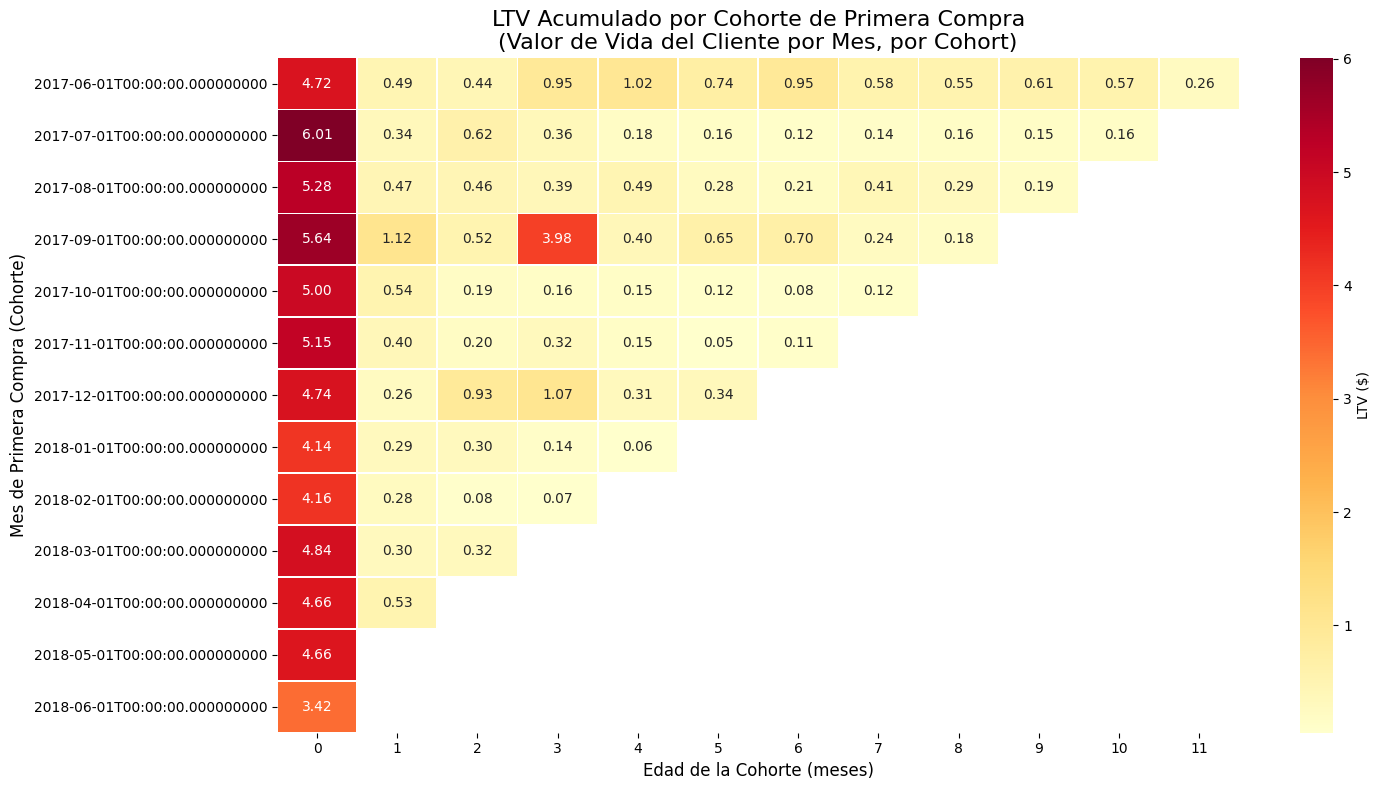

In [129]:
report_pivot = report.pivot_table(
        index="first_purchase_M",
        columns="age",
        values= "ltv",
)

plt.figure(figsize=(15, 8))
sns.heatmap(report_pivot,
            annot=True,          
            fmt='.2f',            
            cmap='YlOrRd',        
            cbar_kws={'label': 'LTV ($)'},  
            linewidths=0.5,       
            linecolor='white')    
plt.title('LTV Acumulado por Cohorte de Primera Compra\n(Valor de Vida del Cliente por Mes, por Cohort)', fontsize=16)
plt.xlabel('Edad de la Cohorte (meses)', fontsize=12)
plt.ylabel('Mes de Primera Compra (Cohorte)', fontsize=12)
plt.tight_layout()
plt.show()

- Los valores más altos se concentran en el primer mes de vida de todas las cohortes, lo que indica que los clientes rara vez realizan compras posteriores a su primera transacción.

In [130]:
ltv_junio_2017 = report_pivot.loc["2017-06-01"].sum()
print("En promedio cada cliente de la cohort de junio-2017 genero 11.87 dolares durante todo su ciclo de vida de 12 meses (suma de los resultados de todos los meses dividos entre el edad de la cohort)")
ltv_junio_2017

En promedio cada cliente de la cohort de junio-2017 genero 11.87 dolares durante todo su ciclo de vida de 12 meses (suma de los resultados de todos los meses dividos entre el edad de la cohort)


11.879233811171522

### CAC & ROMI (por cohorts)

In [131]:
report.head()

,first_purchase_M,purchase_month,Revenue,n_buyers,age,ltv
0,2017-06-01,2017-06-01,9557.49,2023,0,4.724414
1,2017-06-01,2017-07-01,981.82,2023,1,0.485329
2,2017-06-01,2017-08-01,885.34,2023,2,0.437637
3,2017-06-01,2017-09-01,1931.30,2023,3,0.954671
4,2017-06-01,2017-10-01,2068.58,2023,4,1.022531


In [132]:
costs

,Source Id,dt,costs,mes
0,1,2017-06-01,75.20,2017-06
1,1,2017-06-02,62.25,2017-06
2,1,2017-06-03,36.53,2017-06
3,1,2017-06-04,55.00,2017-06
4,1,2017-06-05,57.08,2017-06
...,...,...,...,...
2537,10,2018-05-27,9.92,2018-05
2538,10,2018-05-28,21.26,2018-05
2539,10,2018-05-29,11.32,2018-05
2540,10,2018-05-30,33.15,2018-05


In [133]:
cohort_junio_17 = report[report["first_purchase_M"] == "2017-06-01"]
cohort_junio_17

,first_purchase_M,purchase_month,Revenue,n_buyers,age,ltv
0,2017-06-01,2017-06-01,9557.49,2023,0,4.724414
1,2017-06-01,2017-07-01,981.82,2023,1,0.485329
2,2017-06-01,2017-08-01,885.34,2023,2,0.437637
3,2017-06-01,2017-09-01,1931.30,2023,3,0.954671
4,2017-06-01,2017-10-01,2068.58,2023,4,1.022531
5,2017-06-01,2017-11-01,1487.92,2023,5,0.735502
6,2017-06-01,2017-12-01,1922.74,2023,6,0.950440
7,2017-06-01,2018-01-01,1176.56,2023,7,0.581592
8,2017-06-01,2018-02-01,1119.15,2023,8,0.553213
9,2017-06-01,2018-03-01,1225.51,2023,9,0.605788


In [134]:
n_buyers_junio_17 = cohort_junio_17["n_buyers"][0]
n_buyers_junio_17

2023

In [135]:
costs_junio_17 = costs[costs["mes"] == "2017-06"]["costs"].sum()
costs_junio_17

18015.0

In [136]:
cac_junio_2017 = costs_junio_17 / n_buyers_junio_17

In [137]:
print('CAC =', cac_junio_2017)
print('LTV =', ltv_junio_2017)

CAC = 8.905091448344043
LTV = 11.879233811171522


Adquirir cada cliente le costó a la empresa un promedio de 8.9 dolares en la cohort de junio de 2017 en el mes de junio de 2017, mientras que cada cliente genero 11.87 en promedio de lo que genero en todos los meses de vida de su cohort (suma de los resultados de todos los meses dividos entre el edad de la cohort)

- Rentabilidad positiva: LTV ($11.87) > CAC ($8.90) = $2.97 de ganancia neta por cliente (Cohort: 2017-06)

In [138]:
report = report.rename(columns={"purchase_month": "mes"})
report.head()

,first_purchase_M,mes,Revenue,n_buyers,age,ltv
0,2017-06-01,2017-06-01,9557.49,2023,0,4.724414
1,2017-06-01,2017-07-01,981.82,2023,1,0.485329
2,2017-06-01,2017-08-01,885.34,2023,2,0.437637
3,2017-06-01,2017-09-01,1931.30,2023,3,0.954671
4,2017-06-01,2017-10-01,2068.58,2023,4,1.022531


In [139]:
costs["mes"] = costs["mes"].dt.to_timestamp()
group_costs = costs.groupby("mes")["costs"].sum()
group_costs

mes
2017-06-01    18015.00
2017-07-01    18240.59
2017-08-01    14790.54
2017-09-01    24368.91
2017-10-01    36322.88
2017-11-01    37907.88
2017-12-01    38315.35
2018-01-01    33518.52
2018-02-01    32723.03
2018-03-01    30415.27
2018-04-01    22289.38
2018-05-01    22224.27
Name: costs, dtype: float64

In [140]:
report_ = pd.merge(report, group_costs, left_on="first_purchase_M", right_on="mes")
report_['cac'] = report_['costs'] / report_['n_buyers']
report_['romi'] = report_['ltv'] / report_['cac']
report_

,first_purchase_M,mes,Revenue,n_buyers,age,ltv,costs,cac,romi
0,2017-06-01,2017-06-01,9557.49,2023,0,4.724414,18015.00,8.905091,0.530530
1,2017-06-01,2017-07-01,981.82,2023,1,0.485329,18015.00,8.905091,0.054500
2,2017-06-01,2017-08-01,885.34,2023,2,0.437637,18015.00,8.905091,0.049145
3,2017-06-01,2017-09-01,1931.30,2023,3,0.954671,18015.00,8.905091,0.107205
4,2017-06-01,2017-10-01,2068.58,2023,4,1.022531,18015.00,8.905091,0.114825
...,...,...,...,...,...,...,...,...,...
73,2018-03-01,2018-04-01,1063.05,3533,1,0.300892,30415.27,8.608907,0.034951
74,2018-03-01,2018-05-01,1114.87,3533,2,0.315559,30415.27,8.608907,0.036655
75,2018-04-01,2018-04-01,10600.69,2276,0,4.657597,22289.38,9.793225,0.475594
76,2018-04-01,2018-05-01,1209.92,2276,1,0.531599,22289.38,9.793225,0.054282


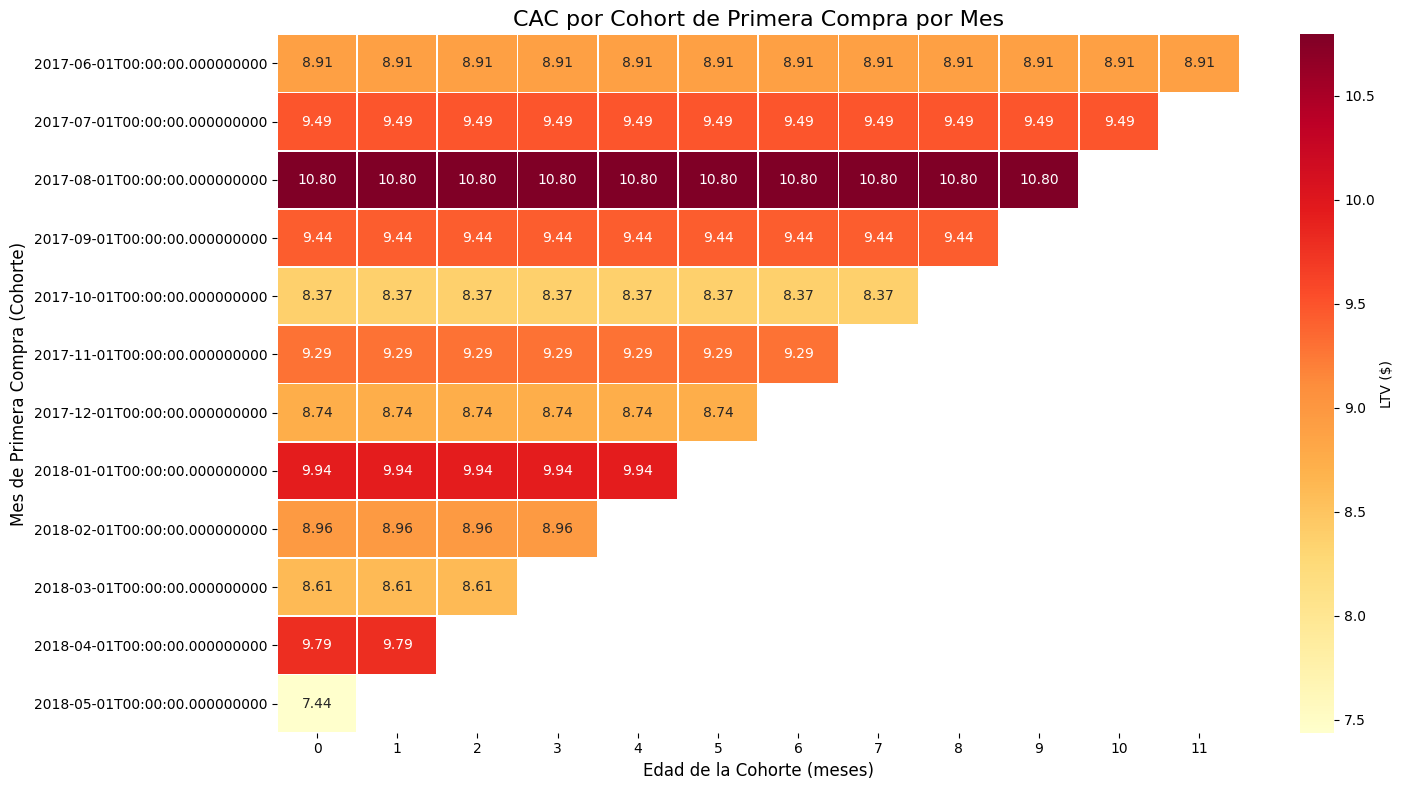

In [141]:
pivot_definitiva = report_.pivot_table(
        index="first_purchase_M",
        columns="age",
        values="cac"
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_definitiva,
            annot=True,          
            fmt='.2f',            
            cmap='YlOrRd',        
            cbar_kws={'label': 'LTV ($)'},  
            linewidths=0.5,       
            linecolor='white')    
plt.title('CAC por Cohort de Primera Compra por Mes', fontsize=16)
plt.xlabel('Edad de la Cohorte (meses)', fontsize=12)
plt.ylabel('Mes de Primera Compra (Cohorte)', fontsize=12)
plt.tight_layout()
plt.show()

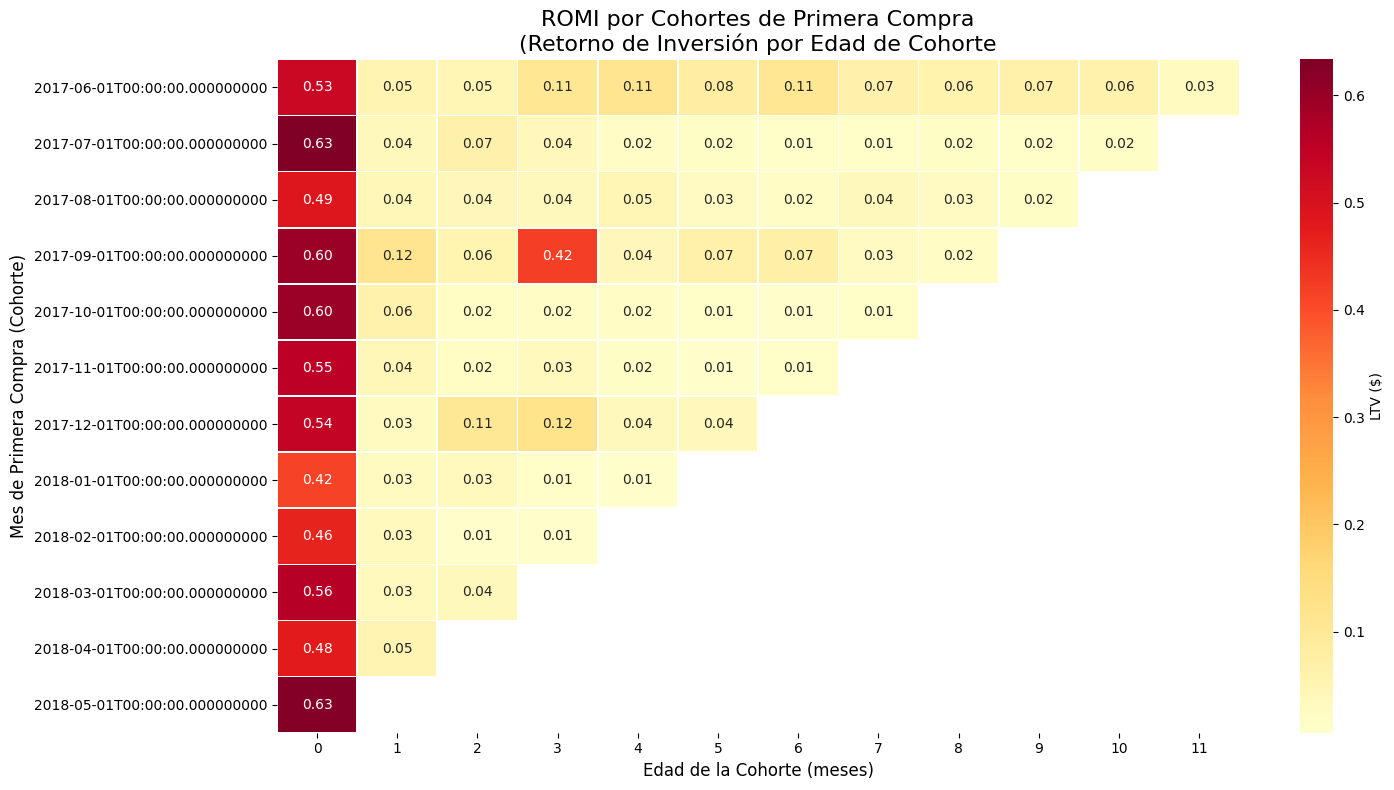

In [143]:
pivot_definitiva_ = report_.pivot_table(
        index="first_purchase_M",
        columns="age",
        values="romi"
)

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_definitiva_,
            annot=True,          
            fmt='.2f',            
            cmap='YlOrRd',        
            cbar_kws={'label': 'LTV ($)'},  
            linewidths=0.5,       
            linecolor='white')    
plt.title('ROMI por Cohortes de Primera Compra\n(Retorno de Inversión por Edad de Cohorte', fontsize=16)
plt.xlabel('Edad de la Cohorte (meses)', fontsize=12)
plt.ylabel('Mes de Primera Compra (Cohorte)', fontsize=12)
plt.tight_layout()
plt.show()

- Hubo mayor ROMI en el primer mes de todas las cohorts, aun asi alcanzando una maximo de 63%, lo cual indica perdida en cuanto lo que se invirtio, se gasto mas de lo que se gano en marketing.
- La cohort de agosto de 2017 destaca por la inversion en marketing que tuvieron en todos los meses de vida de la misma, pero sin embargo tuvo un ROMI bastante pobre de acuerdo a la cantidad de CAC. (ROMI alrededor de 5-15% en la mayoría de meses)
- Cabe destacar que hubo un mes en especifico a diferencia de todos los meses posteriores al primer mes de todas las cohorts que tuvo un 42% de ROMI de la cohort de septiembre de 2017.

# Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde


Las fuentes de adquisicion (Source Id) que predominan sobre las demas son la "1" y la "2". Conviene en terminos de rentabilidad de inversion invertir mas marketing a las fuentes que tiene un CAC moderado y generaron bastante mas de las expectativas en ingresos, por lo que en terminos de ROMI estas fuentes presentan un excelente retorno de inversion; tienen de entre 4,000% a 20,000% (fuentes: 1 y 2),siendo 100% el retorno de lo que se invirtio, indudablemente es necesario invertir mas capital al marketing de estas fuentes; en comparacion a otras fuentes, el ingreso por si solo de estas dos, es mucho mayor a las demas y sin si quiera invertir tanto como con la fuente de adquisicion "3" (ROMI: 100% - 380%); la fuente de adquisicon a la que mas se le invirtio y sin embargo es de las peores en terminos de rentabilidad de inversion. 

La fuente "5" es rentable por el ROMI que arroja por cada mes (rango:900% - 5500%), siendo la tercer fuente mas alta en terminos de rentabilidad. Las demas fuentes de adquisicion (4,9 y 10) no aportaron mucho beneficio en cuanto inversion se refiere pero tampoco quiere decir que no hubo ganancia; se podria seguir invirtiendo en algunos meses y sin alzar mas el presupuesto de inversion, ya que no conviene invertir mas si se gasta mas de lo que se gana en los meses que no hubo un ROMI adecuado considerado por la empresa. 

Existe mayor rentabilidad de inversion en ciertos meses, tambien depende la fuente de adquisicion que influye como factor, pero el mes que beneficia a la mayoria de fuentes es el mes "abril". Especificamente para las fuentes "1" y "2", de "enero" a "marzo" muestran la mas alta rentabilidad; por lo que conviene invertir en "abril" para las fuentes de adquisicon que son rentables de acuerdo al ROMI de ese mes, ademas de invertir mas de acuerdo a la estacionalidad especfica de las fuentes de adquisicion "1" y "2", que va acorde a los meses de "enero" a "marzo".